# Flood-Forecast 6-Month — Persistence & Historical Validation (Tambon scale)

Single-notebook merge of the 4-script pipeline (`config.py`, `01_build_panel.py`,
`02_persistence_maps.py`, `03_validate_vs_history.py`). The standalone `.py`
files are kept; this notebook reproduces them end-to-end and shows the figures
inline.

**Data (IECC)** — everything keyed on the 6-digit Tambon `GEOCODE`:
- `Flood Forecast 6 month/*.xlsx` — 30 monthly 6-month forecasts (202401–202606).
- `TH_TAMBON_json/...adm3...geo.json` — Tambon (ADM3) polygons (`ADM3_PCODE = 'TH'+GEOCODE`).
- `monthly-flood-risk-area.csv` — 17-yr historical monthly flood occurrences + risk class.

**Tasks**
1. **forecast_merge** — same-month report across years: **dark = flagged every year
   (always)**, **light = one year (new)**. Flash flood = red, flood/inundation = blue.
2. **vs_retro** — compare each report-month footprint to the **same calendar month's**
   17-yr climatology (BOTH / FORECAST_ONLY / HISTORY_ONLY / NEITHER).

Analysis years: **2023, 2024 & 2025** (3-year comparison). March compares only
2 years (202303 is missing); 2026 is excluded (only 6 months of data).

Run cells top-to-bottom. The Excel read is cached to `output/*.pkl`.

## Setup & config

Imports plus the inlined contents of `config.py` (paths, risk coding, analysis scope, helpers).

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from IPython.display import Image, display

%matplotlib inline

# ----- paths
IECC = Path("/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC")
FORECAST_DIR = IECC / "Flood Forecast 6 month"
GEOJSON = IECC / "TH_TAMBON_json" / "tha_admbnda_adm3_rtsd_20220121_geo.json"
HIST_CSV = IECC / "monthly-flood-risk-area.csv"

HERE = Path("/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/flood_persistence_analysis")
OUT = HERE / "output"
FIG = HERE / "figures"
OUT.mkdir(exist_ok=True)
(FIG / "forecast_merge").mkdir(parents=True, exist_ok=True)   # Task 1
(FIG / "vs_retro").mkdir(parents=True, exist_ok=True)         # Task 2

# ----- analysis scope: 2023-2025 -> 3-year compare (March has only 2: 202303 missing)
ANALYSIS_YEARS = [2023, 2024, 2025]

# TYPE_E was relabelled mid-series: 'inundation' (<=202405) -> 'flood risk'; same class.
TYPE_TO_CLASS = {
    "norisk": "none",
    "flashflood": "flashflood",
    "inundation": "flood",
    "flood risk": "flood",
}

HIST_RISK_LEVEL = {        # Thai RISK label -> ordinal level
    "เสี่ยงต่ำ": 1,         # 1-3 / 17yr  (low)
    "เสี่ยงปานกลาง": 2,   # 4-8 / 17yr  (medium)
    "เสี่ยงสูง": 3,         # 9-17 / 17yr (high)
}
HIST_LEVEL_EN = {0: "none", 1: "low", 2: "medium", 3: "high"}

MONTH_NAME = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
              7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}


def geocode_from_pcode(pcode) -> str:
    """ADM3_PCODE 'TH100101' -> '100101'."""
    return re.sub(r"^TH", "", str(pcode)).strip()


def report_target_months(issue_month: int) -> list:
    """The 6 calendar months a report issued in issue_month forecasts (wraps)."""
    return [((issue_month - 1 + k) % 12) + 1 for k in range(6)]

## Step 1 — Build the forecast panel  (`01_build_panel.py`)

Load the 30 six-month forecast files into one tidy long panel, then collapse to one row per *(report, Tambon)*: was it flagged flash / flood anywhere in that report's 6-month horizon. Cached to `output/*.pkl` because the Excel read is slow.

In [ ]:
KEEP = ["GEOCODE", "TYPE_E", "YEAR", "MONTH"]


def load_long() -> pd.DataFrame:
    files = sorted(FORECAST_DIR.glob("*FloodForecast_6month.xlsx"))
    if not files:
        raise FileNotFoundError(f"No forecast files under {FORECAST_DIR}")
    seen_types = set()
    frames = []
    for f in files:
        issue = re.match(r"(\d{6})", f.name).group(1)            # '202401'
        raw = pd.read_excel(f)
        if "GEOCODE" not in raw.columns:
            raw["GEOCODE"] = raw["TAMBON_IDN"]
        df = raw[KEEP].copy()
        # some 2023 cells carry openpyxl control-char escapes like 'norisk_x000D_'
        esc = r"_x[0-9A-Fa-f]{4}_"
        df["GEOCODE"] = df["GEOCODE"].astype(str).str.replace(esc, "", regex=True).str.strip()
        df["TYPE_E"] = (df["TYPE_E"].astype(str)
                        .str.replace(esc, "", regex=True).str.strip().str.lower())
        seen_types |= set(df["TYPE_E"].unique())
        df["ISSUE"] = issue
        df["ISSUE_YEAR"] = int(issue[:4])
        df["ISSUE_MONTH"] = int(issue[4:])
        frames.append(df)
        print(f"  loaded {f.name:40s} rows={len(df):>7,}")
    unknown = seen_types - set(TYPE_TO_CLASS)
    if unknown:
        raise ValueError(f"Unexpected TYPE_E values: {unknown}")
    long = pd.concat(frames, ignore_index=True)
    long["CLASS"] = long["TYPE_E"].map(TYPE_TO_CLASS)
    print(f"  -> {len(long):,} rows from {len(files)} files; TYPE_E seen = {sorted(seen_types)}")
    return long


def collapse_by_issue(long: pd.DataFrame) -> pd.DataFrame:
    """One row per (ISSUE, GEOCODE): flagged if class appears in ANY horizon month."""
    g = long.groupby(["ISSUE", "ISSUE_YEAR", "ISSUE_MONTH", "GEOCODE"])
    out = pd.DataFrame({
        "IS_FLASH": g["CLASS"].apply(lambda s: (s == "flashflood").any()),
        "IS_FLOOD": g["CLASS"].apply(lambda s: (s == "flood").any()),
        "N_FLASH_MONTHS": g["CLASS"].apply(lambda s: (s == "flashflood").sum()),
        "N_FLOOD_MONTHS": g["CLASS"].apply(lambda s: (s == "flood").sum()),
    }).reset_index()
    out["AT_RISK"] = out["IS_FLASH"] | out["IS_FLOOD"]
    return out

In [3]:
long_pkl = OUT / "forecast_long.pkl"
by_issue_pkl = OUT / "forecast_by_issue.pkl"

if long_pkl.exists() and by_issue_pkl.exists():
    print("loading cached panel (delete output/*.pkl to rebuild) ...")
    long = pd.read_pickle(long_pkl)
    by_issue = pd.read_pickle(by_issue_pkl)
else:
    print("building panel from 30 Excel files (~1-2 min) ...")
    long = load_long()
    by_issue = collapse_by_issue(long)
    long.to_pickle(long_pkl)
    by_issue.to_pickle(by_issue_pkl)

print("\n================= PANEL SUMMARY =================")
print(f"Reports (ISSUE) ............ {long['ISSUE'].nunique()} ({long['ISSUE'].min()}..{long['ISSUE'].max()})")
print(f"Tambons (GEOCODE) .......... {long['GEOCODE'].nunique():,}")
print(f"Analysis years ............. {ANALYSIS_YEARS}")

# restrict to the analysis years; used by both tasks
by_issue_a = by_issue[by_issue["ISSUE_YEAR"].isin(ANALYSIS_YEARS)].copy()

loading cached panel (delete output/*.pkl to rebuild) ...



================= PANEL SUMMARY =================
Reports (ISSUE) ............ 41 (202301..202606)
Tambons (GEOCODE) .......... 7,387
Analysis years ............. [2023, 2024, 2025]


## Task 1 — Same-month-report persistence  (`02_persistence_maps.py` → `figures/forecast_merge/`)

For each issue-month, count in how many of the 3 analysis years each Tambon was flagged flash / flood. The colour ramp adapts to the year count: level 1 = lightest (**new**), middle = 2 yrs, top = darkest (**always**). So most months show **3 colour levels**; March shows 2 (202303 missing). Flash = red, flood = blue.

In [ ]:
NONE_GREY = "#f0f0f0"   # not flagged (background)
# level 1 = lightest (NEW / 1 yr), top level = darkest (ALWAYS). Sized to n_years.
FLASH_RAMP = {1: ["#cb181d"],
              2: ["#fcae91", "#cb181d"],
              3: ["#fcae91", "#fb6a4a", "#cb181d"]}
FLOOD_RAMP = {1: ["#2171b5"],
              2: ["#bdd7e7", "#2171b5"],
              3: ["#bdd7e7", "#6baed6", "#2171b5"]}


def shade_ramp(kind: str, n_years: int) -> list:
    """[grey, light .. dark] with n_years data colours; ALWAYS = darkest."""
    ramp = FLASH_RAMP if kind == "FLASH" else FLOOD_RAMP
    return [NONE_GREY] + ramp[n_years]


def load_tambon_gdf() -> gpd.GeoDataFrame:
    """Tambon polygons, one per GEOCODE, lightly simplified for national rendering."""
    print("  reading Tambon polygons ...")
    gdf = gpd.read_file(GEOJSON)
    gdf["GEOCODE"] = gdf["ADM3_PCODE"].map(geocode_from_pcode)
    gdf["geometry"] = gdf.geometry.simplify(0.004, preserve_topology=True)
    gdf = gdf.dissolve(by="GEOCODE", as_index=False)
    return gdf[["GEOCODE", "ADM1_EN", "geometry"]]


def build_persistence(by_issue: pd.DataFrame) -> pd.DataFrame:
    """Per (ISSUE_MONTH, GEOCODE): #years flagged flash / flood, and which years."""
    rows = []
    for m, grp in by_issue.groupby("ISSUE_MONTH"):
        years = sorted(grp["ISSUE_YEAR"].unique())
        n_years = len(years)
        flash = (grp[grp["IS_FLASH"]].groupby("GEOCODE")["ISSUE_YEAR"]
                 .apply(lambda s: sorted(s.unique())))
        flood = (grp[grp["IS_FLOOD"]].groupby("GEOCODE")["ISSUE_YEAR"]
                 .apply(lambda s: sorted(s.unique())))
        codes = set(flash.index) | set(flood.index)
        for gc in codes:
            fy = flash.get(gc, [])
            dy = flood.get(gc, [])
            rows.append({
                "ISSUE_MONTH": m, "N_YEARS": n_years, "GEOCODE": gc,
                "FLASH_NYEARS": len(fy), "FLOOD_NYEARS": len(dy),
                "FLASH_YEARS": ",".join(map(str, fy)),
                "FLOOD_YEARS": ",".join(map(str, dy)),
            })
    return pd.DataFrame(rows)


def _persistence_label(kind: str, n_years: int) -> list:
    lab = ["not flagged"]
    for k in range(1, n_years + 1):
        if k == 1:
            lab.append("1 yr  (new)")
        elif k == n_years:
            lab.append(f"{k} yrs (always)")
        else:
            lab.append(f"{k} yrs")
    return lab


def plot_month(gdf, pers, m, kind, ax=None, standalone=True):
    """kind in {'FLASH','FLOOD'}. Saves a PNG when standalone."""
    col = "FLASH_NYEARS" if kind == "FLASH" else "FLOOD_NYEARS"
    title_kind = "Flash flood" if kind == "FLASH" else "Flood / inundation"
    sub = pers[pers["ISSUE_MONTH"] == m]
    n_years = int(sub["N_YEARS"].iloc[0]) if len(sub) else 0
    g = gdf.merge(sub[["GEOCODE", col]], on="GEOCODE", how="left")
    g[col] = g[col].fillna(0).astype(int)
    shades = shade_ramp(kind, n_years)
    cmap = ListedColormap(shades)
    norm = BoundaryNorm(np.arange(-0.5, n_years + 1.5, 1), cmap.N)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 9))
    g.plot(column=col, cmap=cmap, norm=norm, ax=ax, linewidth=0)
    g.boundary.plot(ax=ax, linewidth=0.05, color="white")
    ax.set_axis_off()
    n_flagged = int((g[col] > 0).sum())
    n_always = int((g[col] == n_years).sum())
    ax.set_title(f"{MONTH_NAME[m]} report - {title_kind}\n"
                 f"{n_years} yrs compared | {n_flagged} Tambons flagged | {n_always} always",
                 fontsize=10)
    if standalone:
        labels = _persistence_label(kind, n_years)
        handles = [Patch(facecolor=shades[i], edgecolor="grey", label=labels[i])
                   for i in range(1, n_years + 1)]
        ax.legend(handles=handles, loc="lower left", fontsize=8, title="appears in", frameon=True)
        fig = ax.figure
        fname = FIG / "forecast_merge" / f"{kind.lower()}_month{m:02d}.png"
        fig.tight_layout()
        fig.savefig(fname, dpi=130, bbox_inches="tight")
        plt.close(fig)
        return fname


def contact_sheet_persistence(gdf, pers, kind):
    """3x4 overview of all 12 issue-months for one type."""
    months = sorted(pers["ISSUE_MONTH"].unique())
    fig, axes = plt.subplots(3, 4, figsize=(20, 18))
    for ax, m in zip(axes.ravel(), months):
        plot_month(gdf, pers, m, kind, ax=ax, standalone=False)
    n_years = int(pers["N_YEARS"].max())
    shades = shade_ramp(kind, n_years)
    labels = _persistence_label(kind, n_years)
    handles = [Patch(facecolor=shades[i], edgecolor="grey", label=labels[i])
               for i in range(1, n_years + 1)]
    fig.legend(handles=handles, loc="lower center", ncol=n_years, fontsize=12,
               title="appears in N of the compared years")
    kind_t = "Flash flood (red)" if kind == "FLASH" else "Flood / inundation (blue)"
    fig.suptitle(f"Same-month-report persistence across years - {kind_t}", fontsize=18, y=0.995)
    out = FIG / "forecast_merge" / f"_contact_{kind.lower()}.png"
    fig.savefig(out, dpi=110, bbox_inches="tight")
    plt.close(fig)
    return out

In [ ]:
pers = build_persistence(by_issue_a)
pers.to_csv(OUT / "_persistence.csv", index=False)
print(f"wrote _persistence.csv  ({len(pers):,} rows)")

gdf = load_tambon_gdf()   # reused by Task 2

print("rendering per-month maps ...")
for m in sorted(pers["ISSUE_MONTH"].unique()):
    for kind in ("FLASH", "FLOOD"):
        plot_month(gdf, pers, m, kind)

c_flash = contact_sheet_persistence(gdf, pers, "FLASH")
c_flood = contact_sheet_persistence(gdf, pers, "FLOOD")

print("\n========== TASK 1 STABILITY SUMMARY ==========")
for m, sub in pers.groupby("ISSUE_MONTH"):
    ny = int(sub["N_YEARS"].iloc[0])
    for kind, col in (("flash", "FLASH_NYEARS"), ("flood", "FLOOD_NYEARS")):
        s = sub[sub[col] > 0]
        if len(s) == 0:
            continue
        always = (s[col] == ny).sum()
        new = (s[col] == 1).sum()
        print(f"  month {m:>2} {kind:5s}: {len(s):4d} flagged | "
              f"{always:4d} always ({always/len(s):4.0%}) | {new:4d} new-1yr ({new/len(s):4.0%})")

wrote _persistence.csv  (45,773 rows)
  reading Tambon polygons ...


rendering per-month maps ...



========== TASK 1 STABILITY SUMMARY ==========
  month  1 flash:  768 flagged |   98 always ( 13%) |  426 new-1yr ( 55%)
  month  1 flood: 1503 flagged |   47 always (  3%) |  983 new-1yr ( 65%)
  month  2 flash:  640 flagged |  146 always ( 23%) |  287 new-1yr ( 45%)
  month  2 flood: 1848 flagged |   59 always (  3%) | 1431 new-1yr ( 77%)
  month  3 flash:  775 flagged |  432 always ( 56%) |  343 new-1yr ( 44%)
  month  3 flood: 1307 flagged |  328 always ( 25%) |  979 new-1yr ( 75%)
  month  4 flash: 1026 flagged |  536 always ( 52%) |  255 new-1yr ( 25%)
  month  4 flood: 3631 flagged | 1113 always ( 31%) | 1916 new-1yr ( 53%)
  month  5 flash: 1117 flagged |  479 always ( 43%) |  257 new-1yr ( 23%)
  month  5 flood: 4367 flagged | 1591 always ( 36%) | 1816 new-1yr ( 42%)
  month  6 flash: 1248 flagged |  506 always ( 41%) |  291 new-1yr ( 23%)
  month  6 flood: 4720 flagged | 1777 always ( 38%) | 1795 new-1yr ( 38%)
  month  7 flash: 1259 flagged |  550 always ( 44%) |  235 new-1

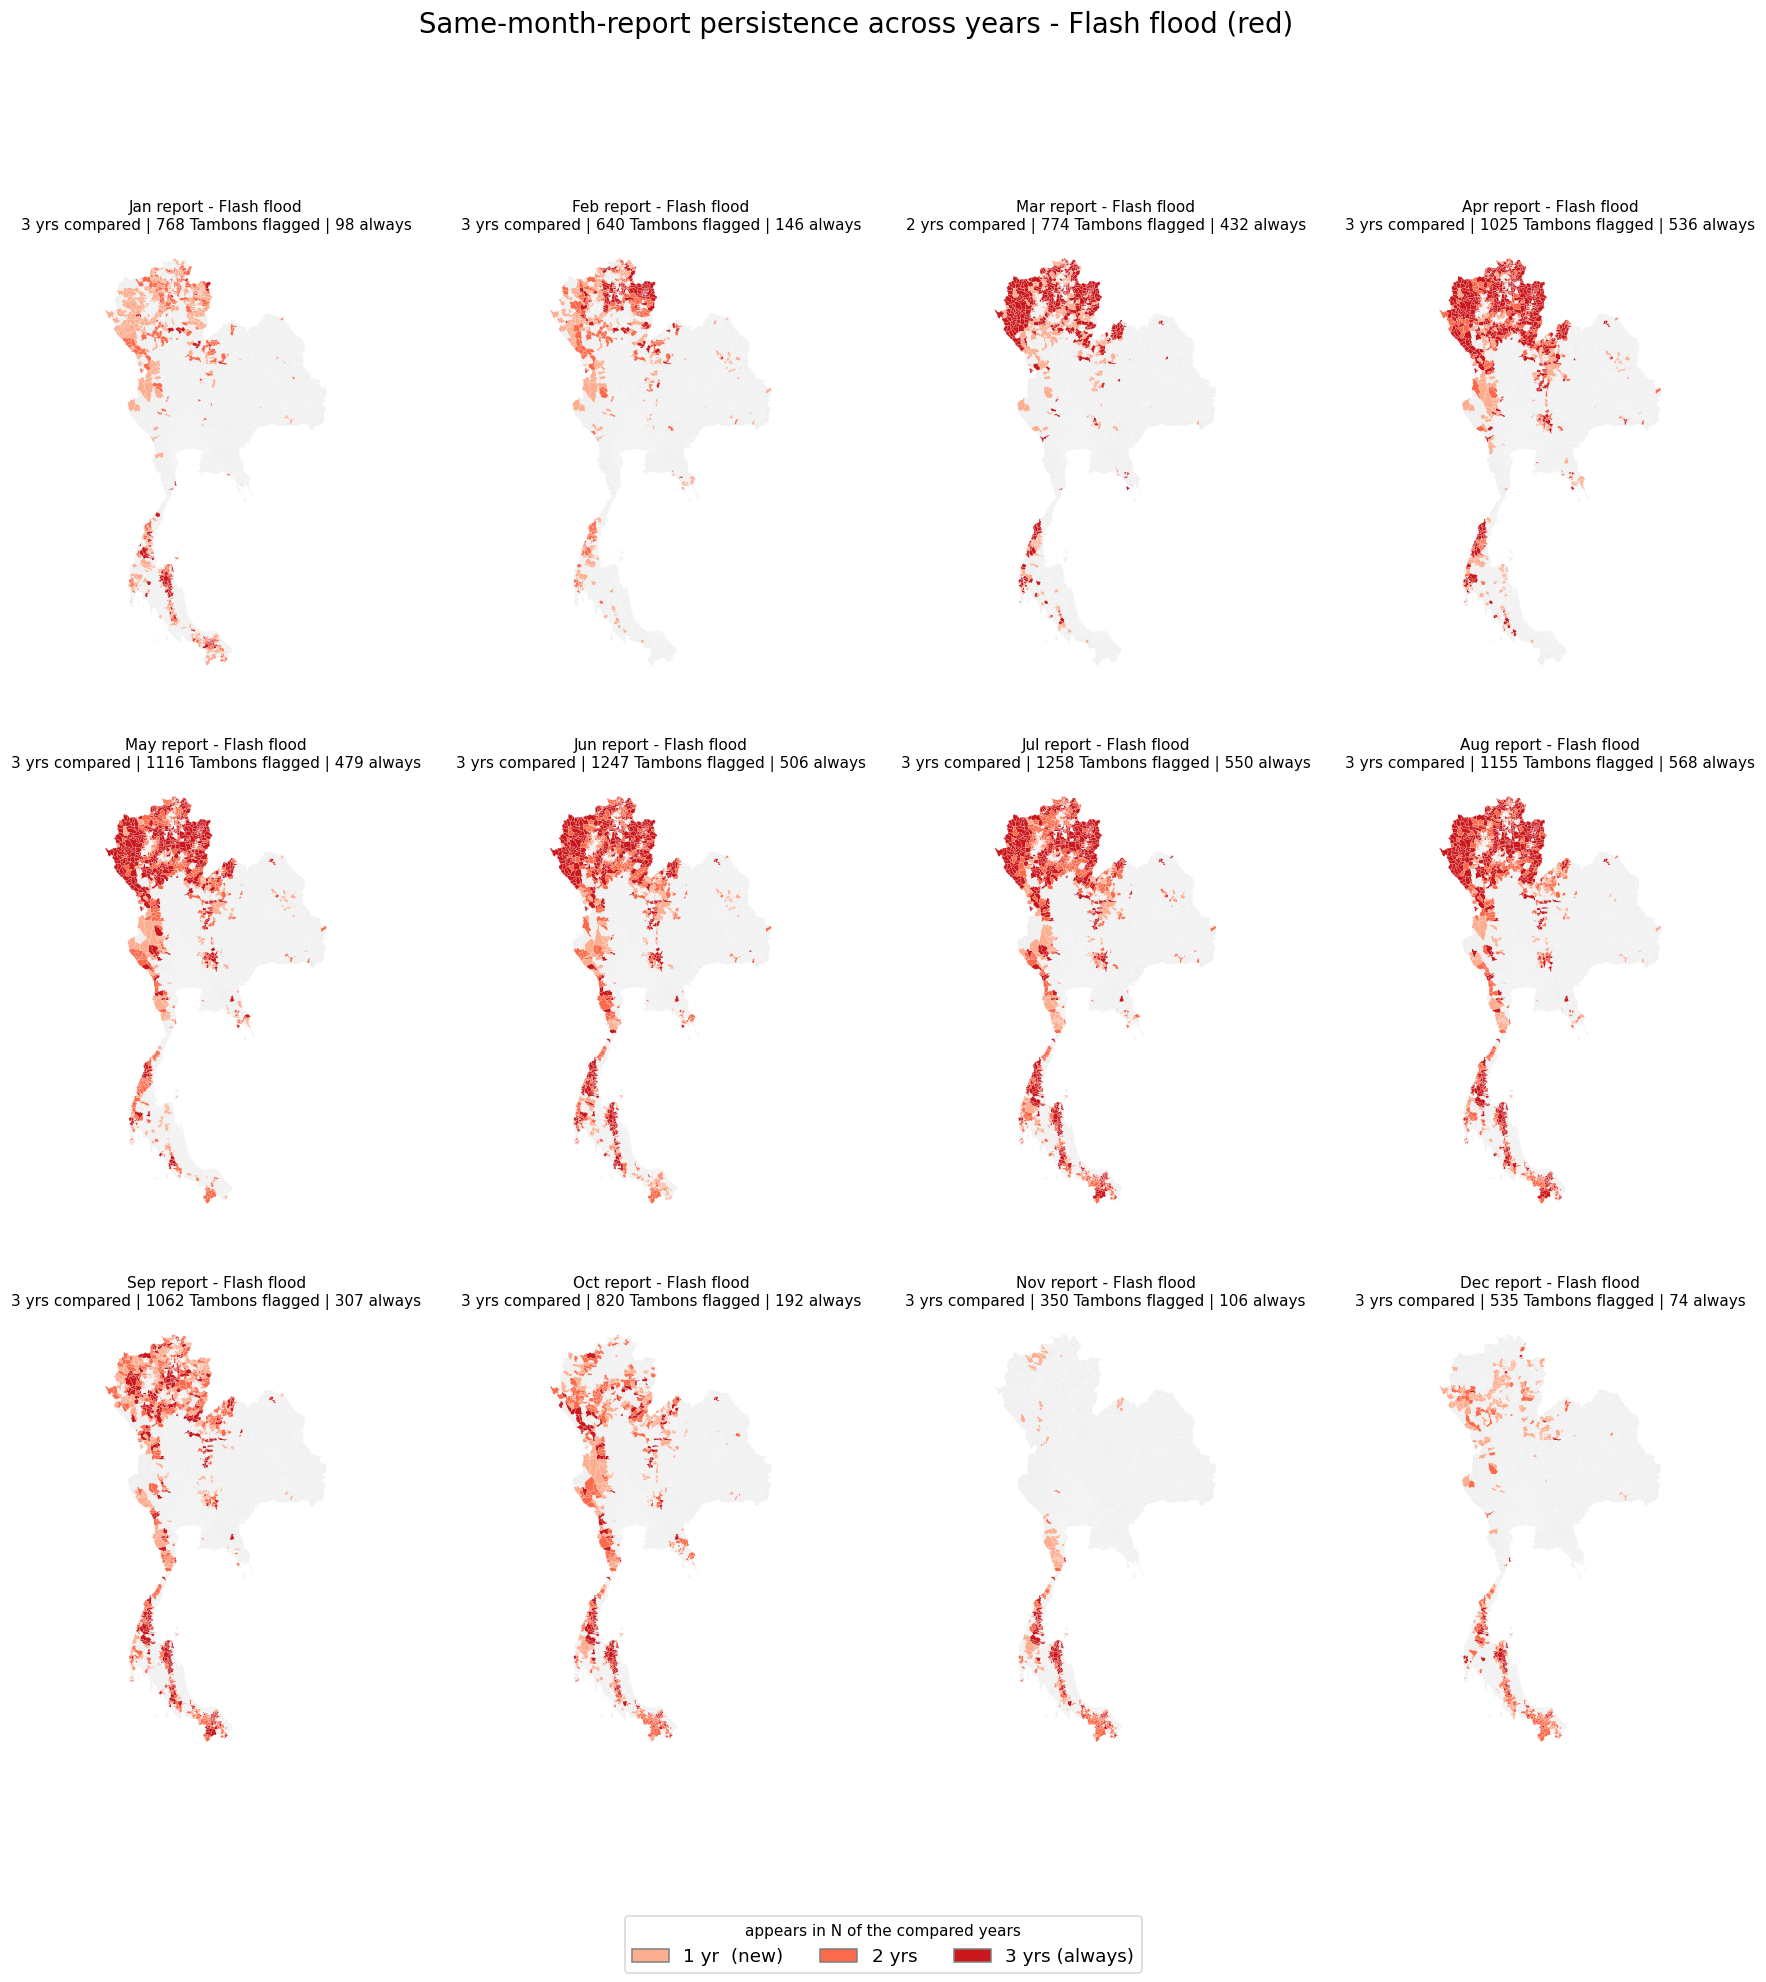

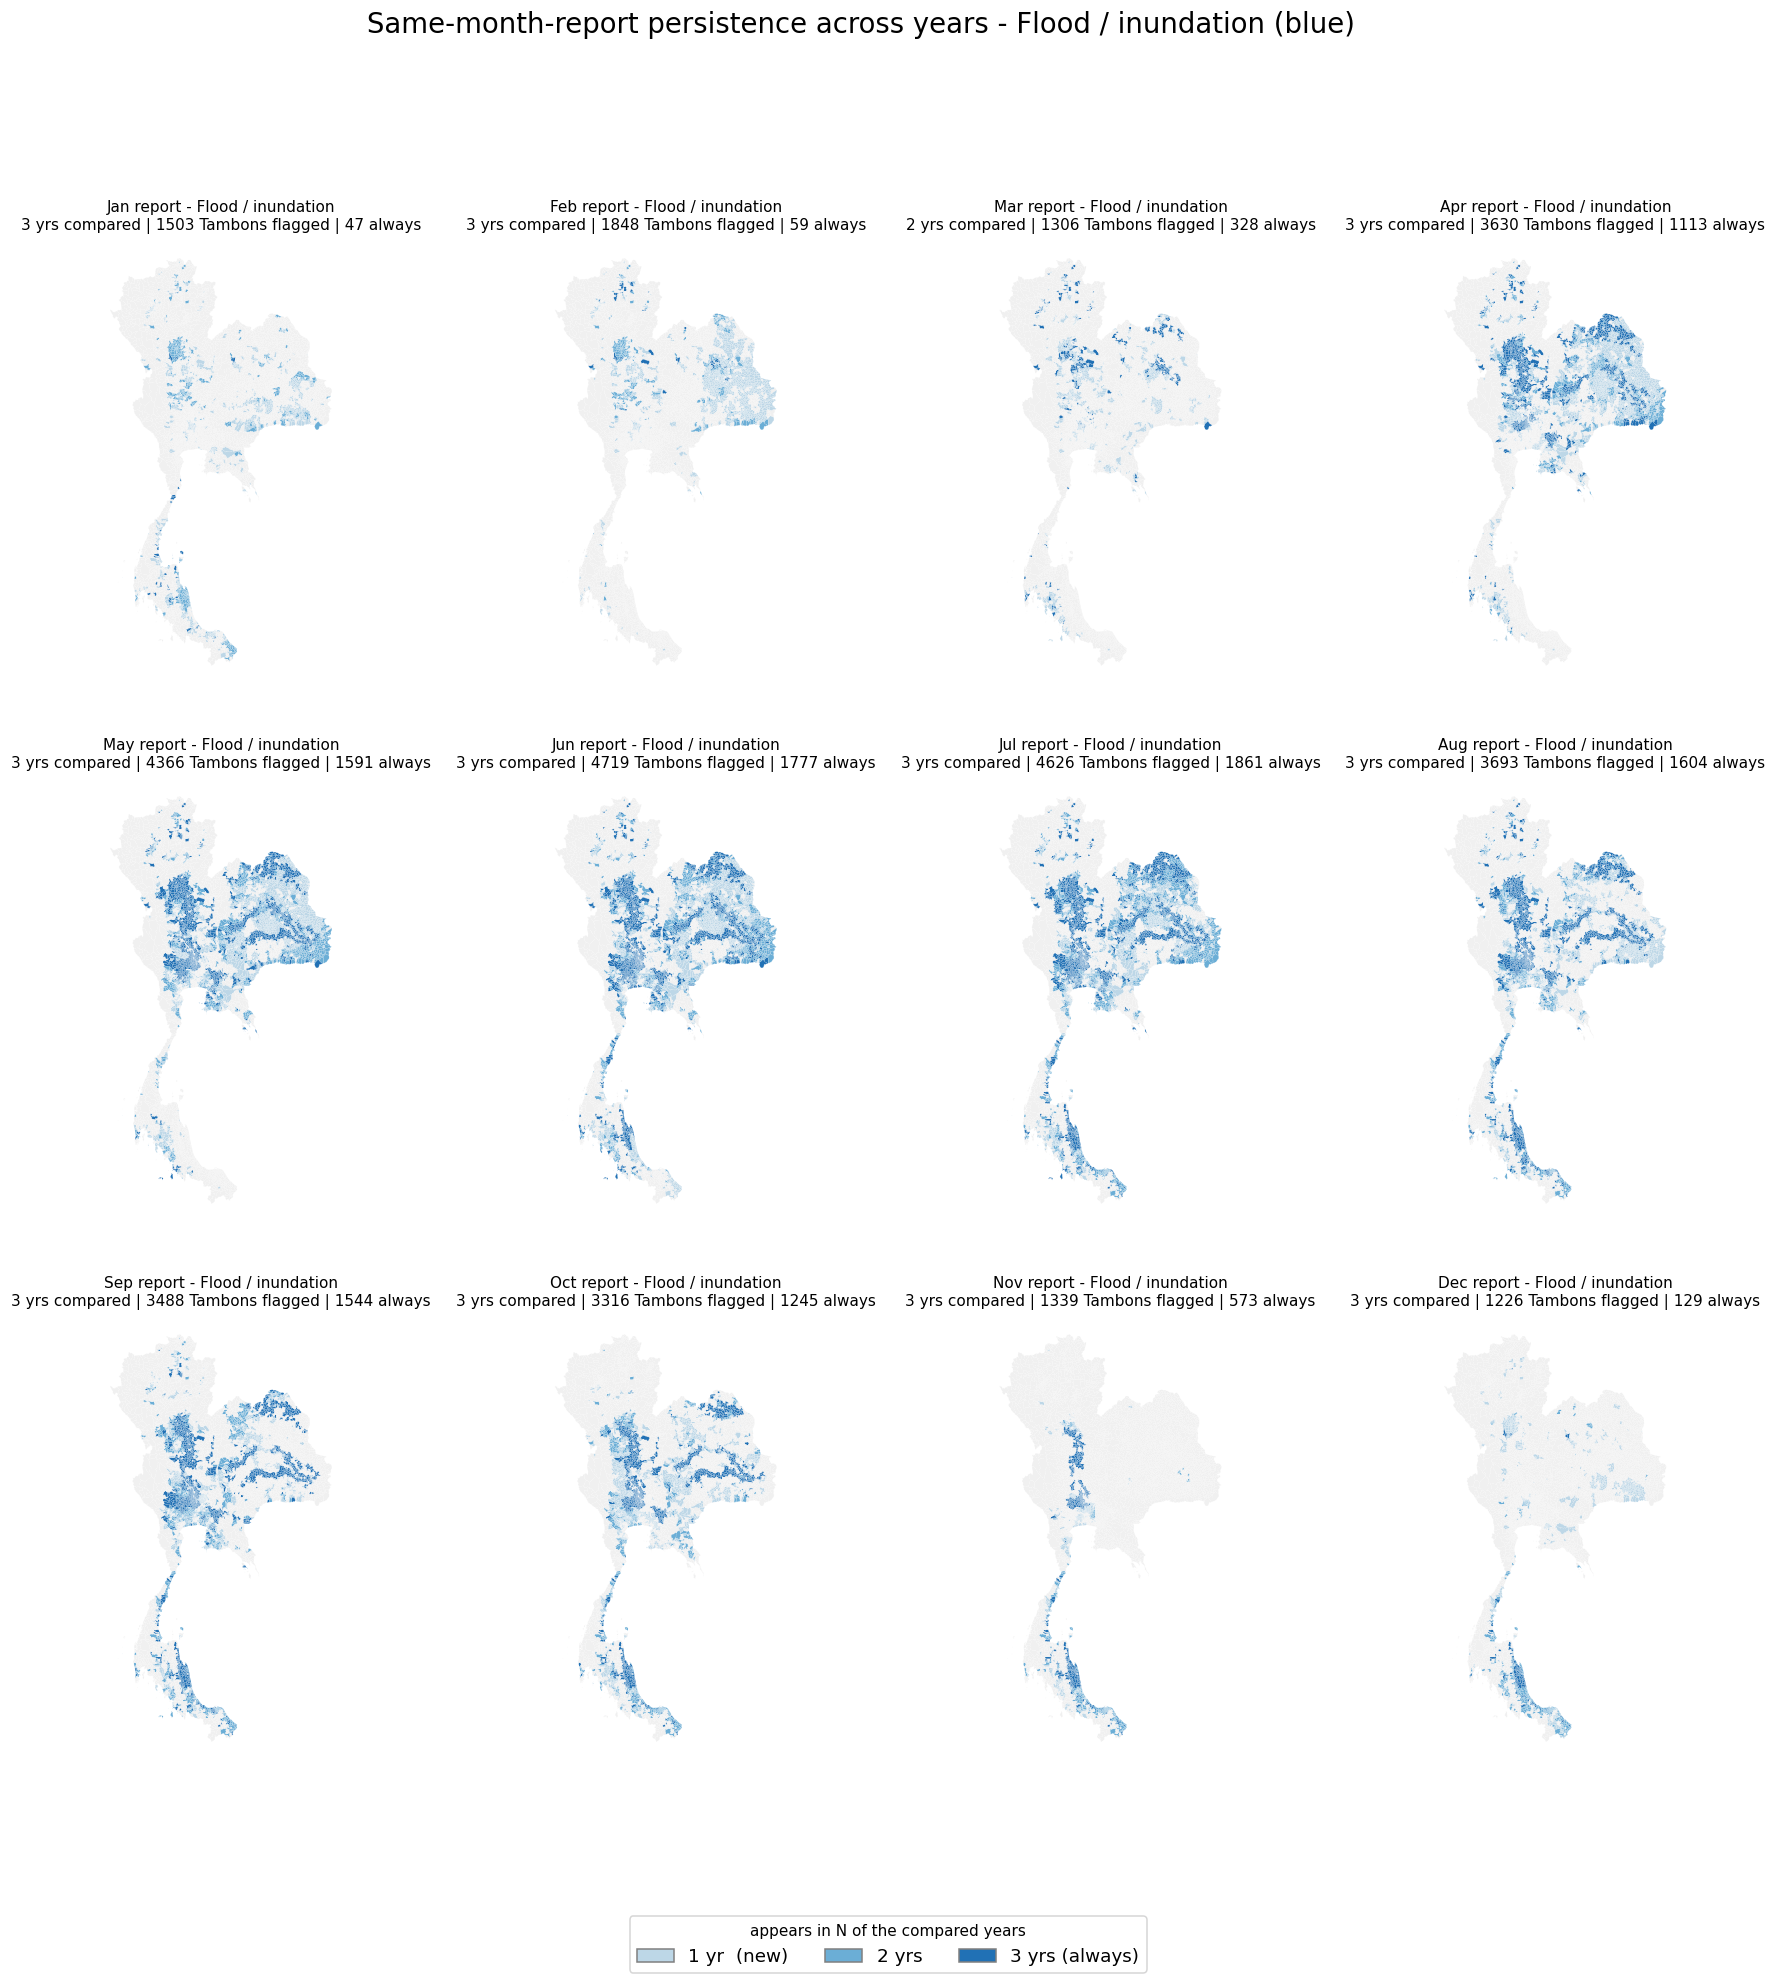

In [6]:
display(Image(str(c_flash)))
display(Image(str(c_flood)))

## Task 2 — Validate vs 17-yr climatology  (`03_validate_vs_history.py` → `figures/vs_retro/`)

Each report-month footprint (the Task-1 map) is compared to the **same calendar month's** 17-yr history. Classes: **BOTH**, **FORECAST_ONLY** (flagged, no history that month), **HISTORY_ONLY** (history that month, not flagged), **NEITHER**. `plot_pers_vs_hist` checks whether persistently-forecast areas line up with high historical occurrence.

In [ ]:
AGREE_ORDER = ["NEITHER", "HISTORY_ONLY", "FORECAST_ONLY", "BOTH"]
AGREE_COLOR = {"NEITHER": "#eeeeee", "HISTORY_ONLY": "#fdae61",
               "FORECAST_ONLY": "#5e3c99", "BOTH": "#1a9641"}


def load_hist() -> pd.DataFrame:
    df = pd.read_csv(HIST_CSV)
    df["GEOCODE"] = df["GEOCODE"].astype(str).str.strip()
    df["HLEVEL"] = df["RISK"].map(HIST_RISK_LEVEL).fillna(0).astype(int)
    df = df.rename(columns={"COUNT 17 YEAR": "HCOUNT"})
    return df[["Month", "GEOCODE", "HCOUNT", "HLEVEL"]]


def hist_window(hist: pd.DataFrame, months: list) -> pd.DataFrame:
    """Aggregate historical risk over a set of calendar months, per Tambon."""
    sub = hist[hist["Month"].isin(months)]
    g = sub.groupby("GEOCODE").agg(
        HCOUNT_MAX=("HCOUNT", "max"),
        HLEVEL_MAX=("HLEVEL", "max"),
        HMONTHS=("Month", "nunique"),
    ).reset_index()
    return g


def build_agreement(by_issue, hist, pers):
    """SAME month vs SAME month: report-month M footprint vs history month M."""
    universe = sorted(by_issue["GEOCODE"].unique())
    recs = []
    for m in range(1, 13):
        if m not in set(by_issue["ISSUE_MONTH"]):
            continue
        months = [m]
        gi = by_issue[by_issue["ISSUE_MONTH"] == m]
        fc = gi.groupby("GEOCODE").agg(
            FC_FLASH=("IS_FLASH", "any"),
            FC_FLOOD=("IS_FLOOD", "any"),
            FC_ANY=("AT_RISK", "any"),
        )
        hw = hist_window(hist, months).set_index("GEOCODE")
        pv = (pers[pers.ISSUE_MONTH == m]
              .set_index("GEOCODE")[["FLASH_NYEARS", "FLOOD_NYEARS", "N_YEARS"]])
        df = pd.DataFrame(index=universe)
        df["ISSUE_MONTH"] = m
        df = df.join(fc).join(hw).join(pv)
        for c in ["FC_FLASH", "FC_FLOOD", "FC_ANY"]:
            df[c] = df[c].fillna(False)
        for c in ["HCOUNT_MAX", "HLEVEL_MAX", "HMONTHS", "FLASH_NYEARS", "FLOOD_NYEARS"]:
            df[c] = df[c].fillna(0).astype(int)
        df["N_YEARS"] = df["N_YEARS"].fillna(df["N_YEARS"].dropna().max()).astype(int)
        df["FC"] = df["FC_ANY"]
        df["HIST"] = df["HLEVEL_MAX"] > 0
        df["PERS"] = df[["FLASH_NYEARS", "FLOOD_NYEARS"]].max(axis=1)
        df["AGREE"] = np.select(
            [df.FC & df.HIST, df.FC & ~df.HIST, ~df.FC & df.HIST],
            ["BOTH", "FORECAST_ONLY", "HISTORY_ONLY"], default="NEITHER")
        recs.append(df.reset_index().rename(columns={"index": "GEOCODE"}))
    return pd.concat(recs, ignore_index=True)


def validation_summary(agree: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for m, d in agree.groupby("ISSUE_MONTH"):
        nfc = int(d.FC.sum()); nhist = int(d.HIST.sum())
        both = int((d.AGREE == "BOTH").sum())
        fo = int((d.AGREE == "FORECAST_ONLY").sum())
        ho = int((d.AGREE == "HISTORY_ONLY").sum())
        prec = both / nfc if nfc else np.nan
        rec = both / nhist if nhist else np.nan
        hi = d[d.HLEVEL_MAX == 3]
        rec_hi = (hi.FC.sum() / len(hi)) if len(hi) else np.nan
        rows.append({
            "ISSUE_MONTH": m, "MONTH": MONTH_NAME[m], "HIST_MONTH": MONTH_NAME[m],
            "N_FORECAST": nfc, "N_HIST": nhist, "BOTH": both,
            "FORECAST_ONLY": fo, "HISTORY_ONLY": ho,
            "PRECISION_vs_hist": round(prec, 3),
            "RECALL_vs_hist": round(rec, 3),
            "RECALL_hist_HIGH": round(rec_hi, 3) if rec_hi == rec_hi else np.nan,
        })
    return pd.DataFrame(rows)


def persistence_vs_history(agree: pd.DataFrame) -> pd.DataFrame:
    """Cross-tab: Task-1 persistence vs historical risk level (forecast-flagged only)."""
    d = agree[agree.FC].copy()
    ct = pd.crosstab(d["PERS"], d["HLEVEL_MAX"].map(HIST_LEVEL_EN), normalize="index").round(3)
    ct.columns.name = "historical_risk"
    ct.index.name = "forecast_persistence_years"
    ct["mean_hist_count_17yr"] = d.groupby("PERS")["HCOUNT_MAX"].mean().round(2)
    ct["n_tambon_months"] = d.groupby("PERS").size()
    return ct.reset_index().rename(columns={"forecast_persistence_years": "PERS"})


def plot_agreement(gdf, agree, m, ax=None, standalone=True):
    d = agree[agree.ISSUE_MONTH == m][["GEOCODE", "AGREE"]]
    g = gdf.merge(d, on="GEOCODE", how="left")
    g["AGREE"] = g["AGREE"].fillna("NEITHER")
    g["ACODE"] = g["AGREE"].map({a: i for i, a in enumerate(AGREE_ORDER)})
    cmap = ListedColormap([AGREE_COLOR[a] for a in AGREE_ORDER])
    norm = BoundaryNorm(np.arange(-0.5, 4.5, 1), cmap.N)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 9))
    g.plot(column="ACODE", cmap=cmap, norm=norm, ax=ax, linewidth=0)
    g.boundary.plot(ax=ax, linewidth=0.05, color="white")
    ax.set_axis_off()
    vc = g["AGREE"].value_counts()
    ax.set_title(f"{MONTH_NAME[m]} report vs {MONTH_NAME[m]} history\n"
                 f"both={vc.get('BOTH',0)}  fc-only={vc.get('FORECAST_ONLY',0)}  "
                 f"hist-only={vc.get('HISTORY_ONLY',0)}", fontsize=9)
    if standalone:
        handles = [Patch(facecolor=AGREE_COLOR[a], edgecolor="grey", label=a)
                   for a in reversed(AGREE_ORDER)]
        ax.legend(handles=handles, loc="lower left", fontsize=8, frameon=True)
        fig = ax.figure
        out = FIG / "vs_retro" / f"agreement_month{m:02d}.png"
        fig.tight_layout(); fig.savefig(out, dpi=130, bbox_inches="tight")
        plt.close(fig)
        return out


def contact_sheet_agreement(gdf, agree):
    months = sorted(agree.ISSUE_MONTH.unique())
    fig, axes = plt.subplots(3, 4, figsize=(20, 18))
    for ax, m in zip(axes.ravel(), months):
        plot_agreement(gdf, agree, m, ax=ax, standalone=False)
    handles = [Patch(facecolor=AGREE_COLOR[a], edgecolor="grey", label=a)
               for a in reversed(AGREE_ORDER)]
    fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=12)
    fig.suptitle("Report-month footprint vs SAME-month 17-yr flood climatology", fontsize=18, y=0.995)
    out = FIG / "vs_retro" / "_contact_agreement.png"
    fig.savefig(out, dpi=110, bbox_inches="tight"); plt.close(fig)
    return out


def plot_pers_vs_hist(pvh):
    levels = [c for c in ["none", "low", "medium", "high"] if c in pvh.columns]
    fig, ax = plt.subplots(figsize=(8, 5))
    bottom = np.zeros(len(pvh))
    colors = {"none": "#dddddd", "low": "#fee08b", "medium": "#fc8d59", "high": "#d73027"}
    for lv in levels:
        ax.bar(pvh["PERS"].astype(int).astype(str), pvh[lv], bottom=bottom, label=lv, color=colors[lv])
        bottom += pvh[lv].values
    ax.set_xlabel("forecast persistence (years the report flagged the Tambon)")
    ax.set_ylabel("share of forecast-flagged Tambon-months")
    ax.set_title("Do persistently-forecast areas match historical flood risk?")
    ax.legend(title="17-yr historical risk", loc="upper left", bbox_to_anchor=(1, 1))
    for i, (_, r) in enumerate(pvh.iterrows()):
        ax.text(i, 1.02, f"n={int(r['n_tambon_months'])}\nmu_cnt={r['mean_hist_count_17yr']}",
                ha="center", va="bottom", fontsize=8)
    fig.tight_layout()
    out = FIG / "vs_retro" / "persistence_vs_history.png"
    fig.savefig(out, dpi=130, bbox_inches="tight"); plt.close(fig)
    return out

In [ ]:
hist = load_hist()

agree = build_agreement(by_issue_a, hist, pers)
agree.to_csv(OUT / "_agreement_byreport.csv", index=False)

summ = validation_summary(agree)
summ.to_csv(OUT / "_validation_summary.csv", index=False)

pvh = persistence_vs_history(agree)
pvh.to_csv(OUT / "_persistence_vs_history.csv", index=False)

print("rendering agreement maps ...")
for m in sorted(agree["ISSUE_MONTH"].unique()):
    plot_agreement(gdf, agree, m)
c_agree = contact_sheet_agreement(gdf, agree)
c_pvh = plot_pers_vs_hist(pvh)

tot_both = int((agree.AGREE == "BOTH").sum())
tot_fc = int(agree.FC.sum())
tot_hist = int(agree.HIST.sum())
print("\n========== TASK 2 HEADLINE ==========")
print(f"Forecast-flagged Tambon-months ...... {tot_fc:,}")
print(f"  of which historically flood ....... {tot_both:,} ({tot_both/tot_fc:.0%})  <- precision")
print(f"Historically-flooding Tambon-months . {tot_hist:,}")
print(f"  of which forecast flagged ......... {tot_both:,} ({tot_both/tot_hist:.0%})  <- recall")

rendering agreement maps ...



========== TASK 2 HEADLINE ==========
Forecast-flagged Tambon-months ...... 45,773
  of which historically flood ....... 15,857 (35%)  <- precision
Historically-flooding Tambon-months . 27,023
  of which forecast flagged ......... 15,857 (59%)  <- recall


,ISSUE_MONTH,MONTH,HIST_MONTH,N_FORECAST,N_HIST,BOTH,FORECAST_ONLY,HISTORY_ONLY,PRECISION_vs_hist,RECALL_vs_hist,RECALL_hist_HIGH
0,1,Jan,Jan,2271,764,485,1786,279,0.214,0.635,NaN
1,2,Feb,Feb,2488,620,65,2423,555,0.026,0.105,NaN
2,3,Mar,Mar,2082,345,32,2050,313,0.015,0.093,NaN
3,4,Apr,Apr,4657,560,177,4480,383,0.038,0.316,NaN
4,5,May,May,5484,1159,965,4519,194,0.176,0.833,NaN
5,6,Jun,Jun,5968,2432,2003,3965,429,0.336,0.824,NaN
6,7,Jul,Jul,5885,2854,2395,3490,459,0.407,0.839,NaN
7,8,Aug,Aug,4849,3254,2235,2614,1019,0.461,0.687,1.000
8,9,Sep,Sep,4551,4536,2799,1752,1737,0.615,0.617,0.950
9,10,Oct,Oct,4137,4310,2582,1555,1728,0.624,0.599,0.935


historical_risk,PERS,high,low,medium,none,mean_hist_count_17yr,n_tambon_months
0,1,0.006,0.190,0.077,0.726,0.77,18585
1,2,0.007,0.211,0.079,0.704,0.82,12082
2,3,0.127,0.232,0.117,0.524,2.43,15106


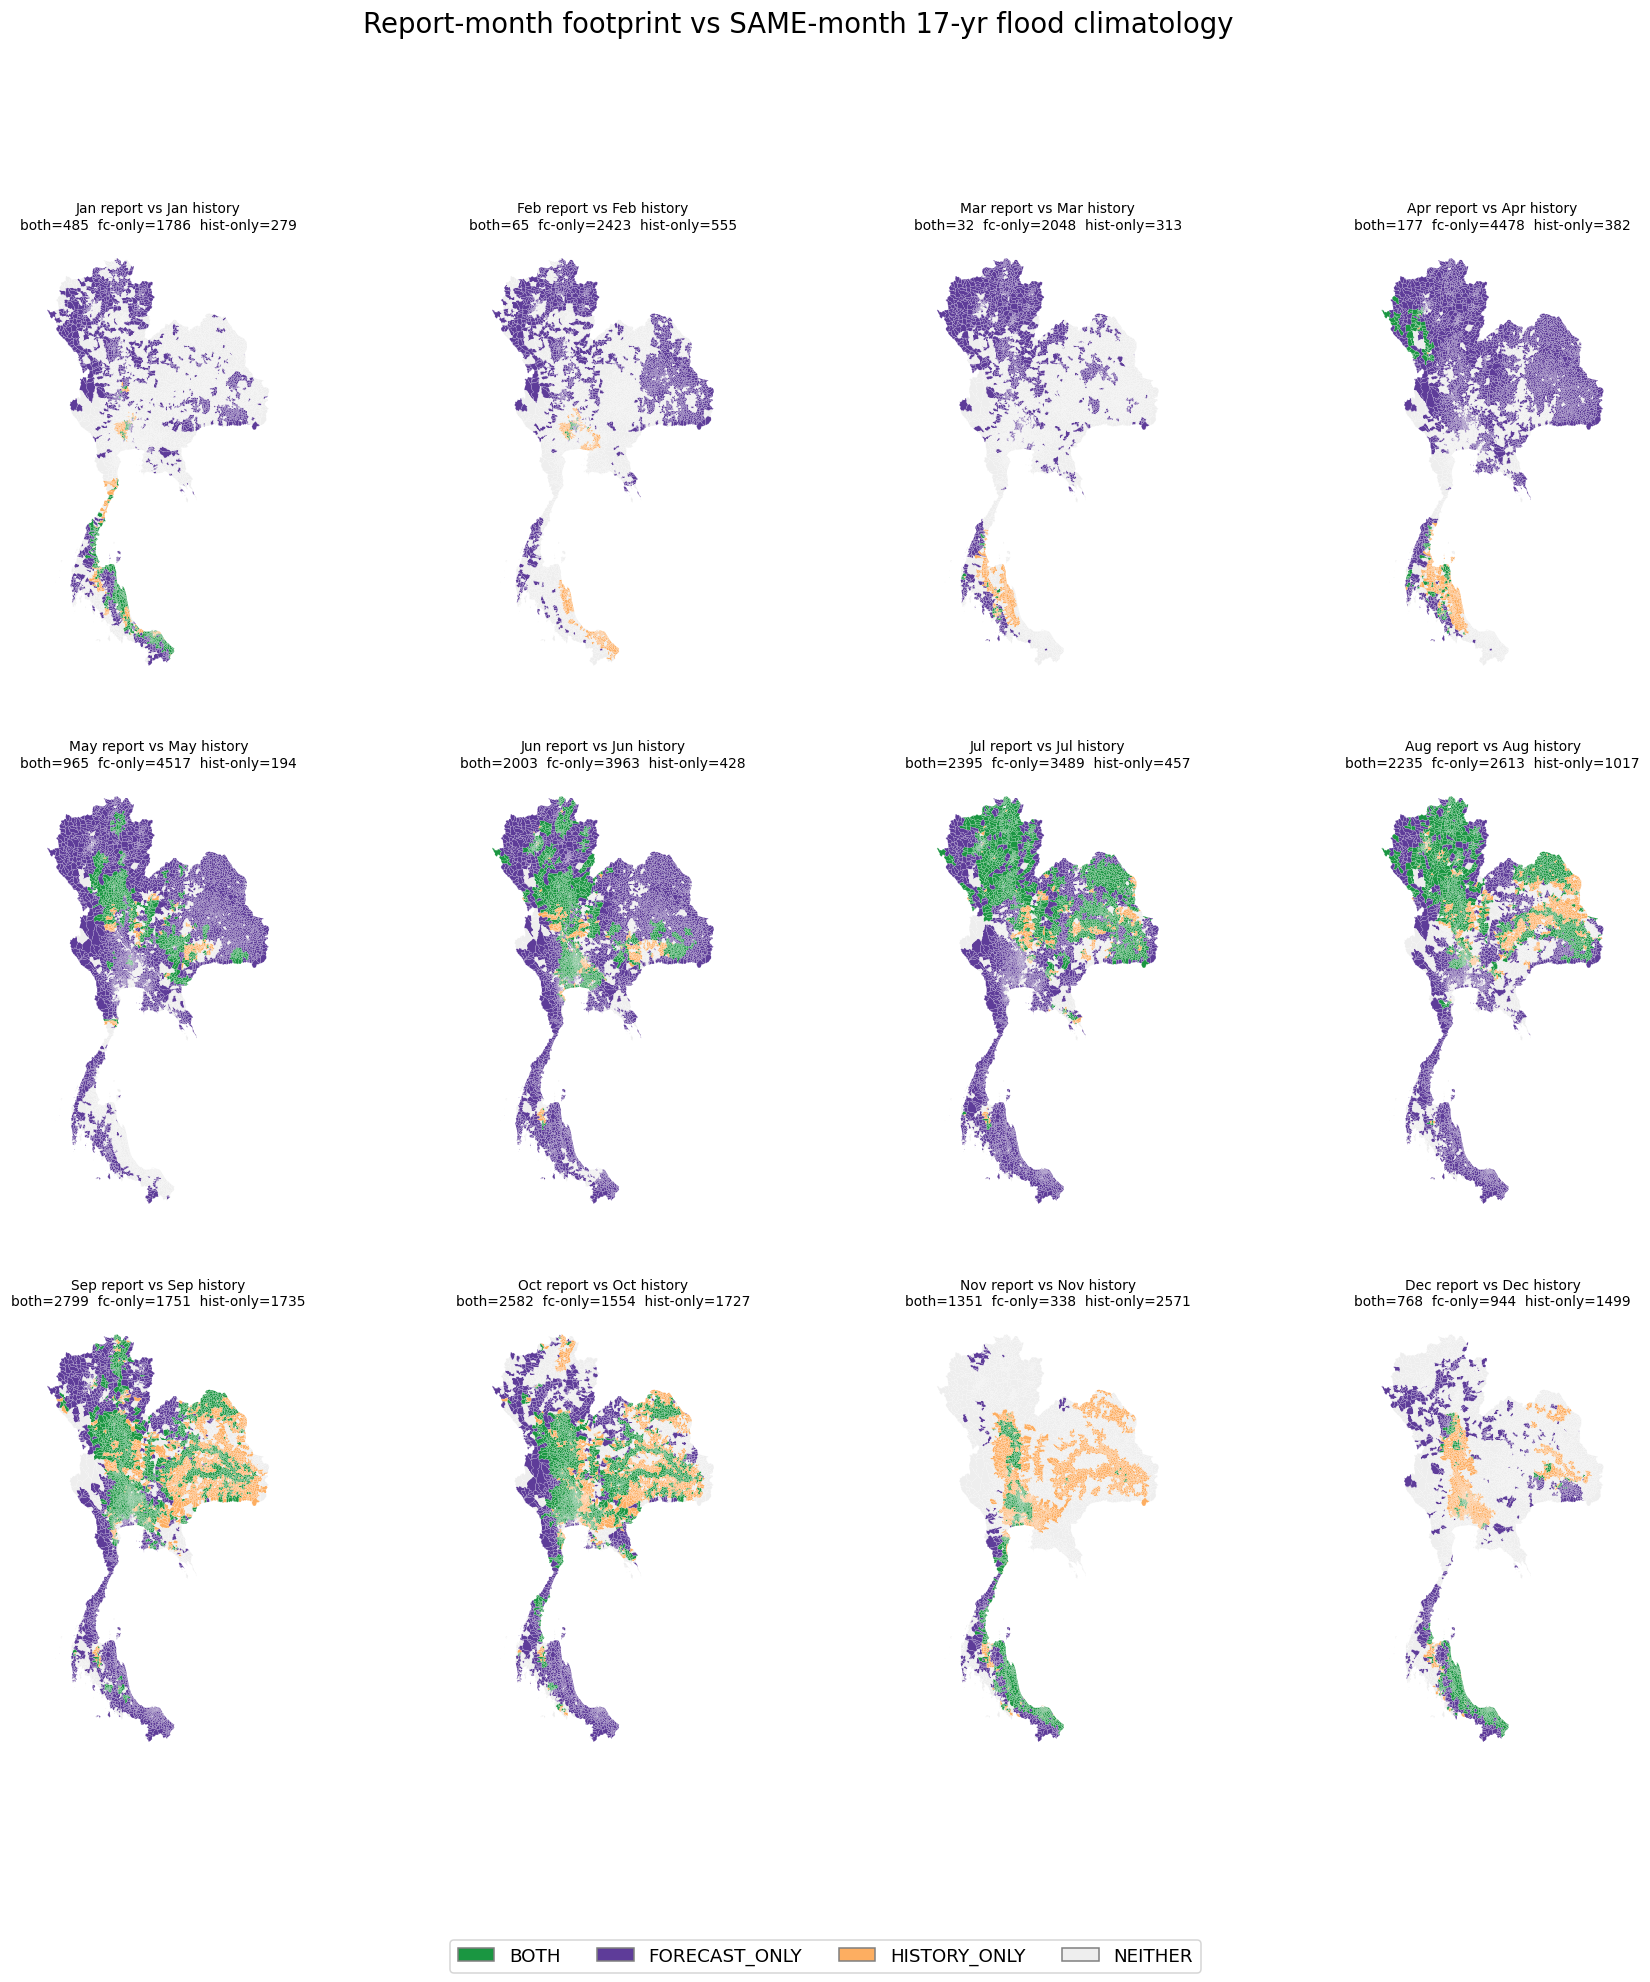

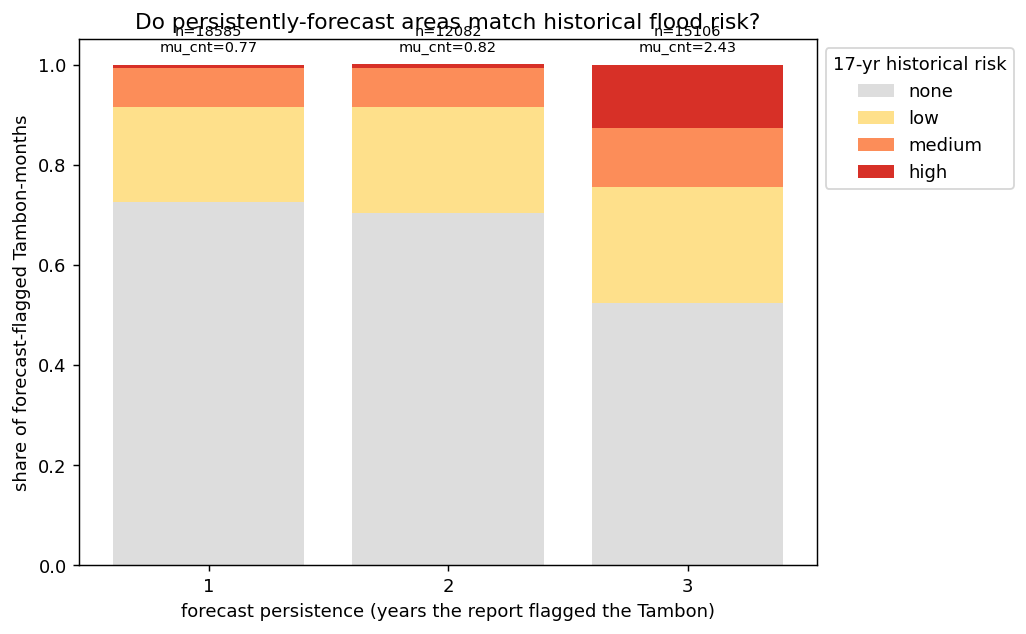

In [9]:
display(summ)
display(pvh)
display(Image(str(c_agree)))
display(Image(str(c_pvh)))